Dataset Loaded Successfully
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

===== Assignment 1: Simple Linear Regression =====


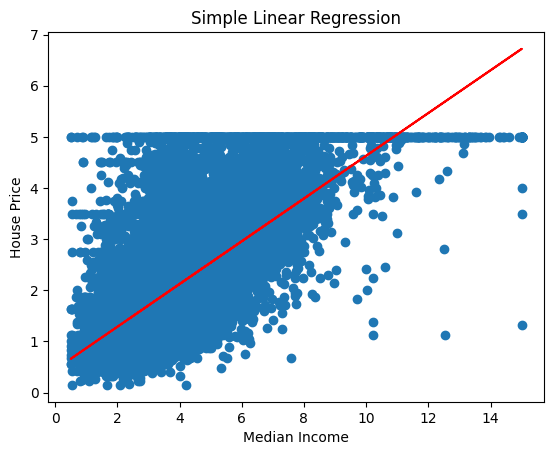


===== Assignment 2: Train/Test + Linear Regression =====
Linear Regression MSE: 0.5558915986952444
Linear Regression R2: 0.5757877060324508

===== Assignment 3: Multiple Linear Regression =====
            Coefficient
MedInc         0.448675
HouseAge       0.009724
AveRooms      -0.123323
AveBedrms      0.783145
Population    -0.000002
AveOccup      -0.003526
Latitude      -0.419792
Longitude     -0.433708


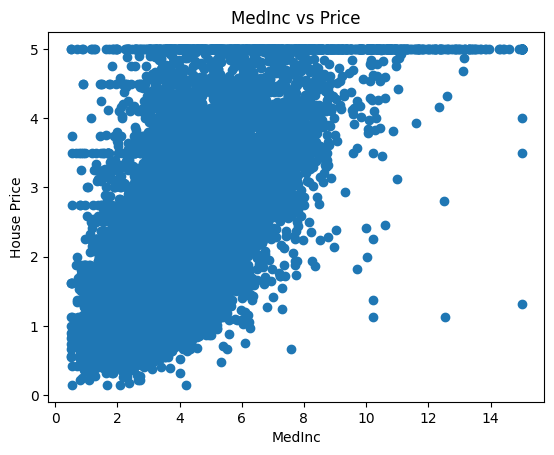

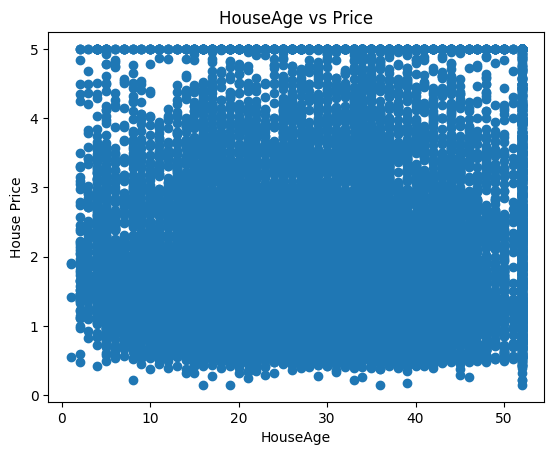

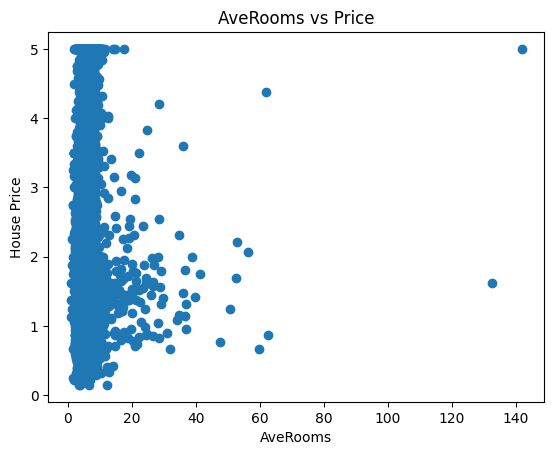


===== Assignment 4: Model Comparison =====

Linear
MSE: 0.5558915986952444
R2: 0.5757877060324508

Ridge
MSE: 0.5558034669932211
R2: 0.5758549611440126

Lasso
MSE: 0.6135115198058131
R2: 0.5318167610318159

Comparison Table:
     Model       MSE        R2
0  Linear  0.555892  0.575788
1   Ridge  0.555803  0.575855
2   Lasso  0.613512  0.531817

===== Assignment 5: Residual Analysis =====


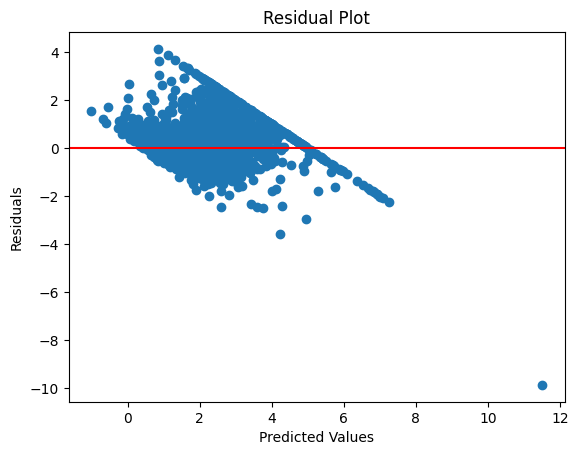


===== Assignment 6: Feature Engineering =====
Original R2: 0.5757877060324508
Polynomial R2: 0.6456819711504156


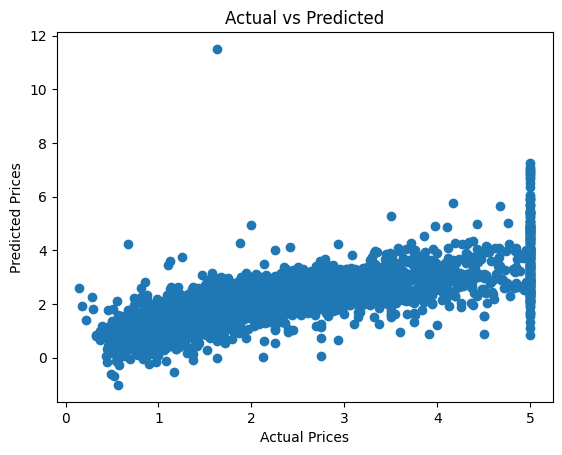

In [1]:
# ============================================
# COMPLETE REGRESSION ASSIGNMENT (ALL TASKS)
# House Price Prediction - California Dataset
# ============================================

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

# ============================================
# LOAD DATASET
# ============================================

data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset Loaded Successfully")
print(X.head())

# ============================================
# ASSIGNMENT 1: SIMPLE LINEAR REGRESSION
# ============================================

print("\n===== Assignment 1: Simple Linear Regression =====")

# Using only one feature (MedInc)
X_simple = X[['MedInc']]

model_simple = LinearRegression()
model_simple.fit(X_simple, y)

y_pred_simple = model_simple.predict(X_simple)

# Plot
plt.scatter(X_simple, y)
plt.plot(X_simple, y_pred_simple, color='red')
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")
plt.show()

# ============================================
# ASSIGNMENT 2: TRAIN TEST SPLIT + LINEAR MODEL
# ============================================

print("\n===== Assignment 2: Train/Test + Linear Regression =====")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression MSE:", mse)
print("Linear Regression R2:", r2)

# ============================================
# ASSIGNMENT 3: MULTIPLE LINEAR REGRESSION
# ============================================

print("\n===== Assignment 3: Multiple Linear Regression =====")

coefficients = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print(coefficients)

# Visualization of few features
for col in X.columns[:3]:
    plt.scatter(X[col], y)
    plt.xlabel(col)
    plt.ylabel("House Price")
    plt.title(f"{col} vs Price")
    plt.show()

# ============================================
# ASSIGNMENT 4: MODEL COMPARISON
# ============================================

print("\n===== Assignment 4: Model Comparison =====")

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1)
}

results = []

for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)

    mse_val = mean_squared_error(y_test, pred)
    r2_val = r2_score(y_test, pred)

    results.append([name, mse_val, r2_val])

    print(f"\n{name}")
    print("MSE:", mse_val)
    print("R2:", r2_val)

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=["Model", "MSE", "R2"])
print("\nComparison Table:\n", results_df)

# ============================================
# ASSIGNMENT 5: RESIDUAL ANALYSIS
# ============================================

print("\n===== Assignment 5: Residual Analysis =====")

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# ============================================
# ASSIGNMENT 6: FEATURE ENGINEERING
# ============================================

print("\n===== Assignment 6: Feature Engineering =====")

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y, test_size=0.2, random_state=42)

model_poly = LinearRegression()
model_poly.fit(X_train_p, y_train_p)

y_pred_poly = model_poly.predict(X_test_p)

r2_poly = r2_score(y_test_p, y_pred_poly)

print("Original R2:", r2)
print("Polynomial R2:", r2_poly)

# ============================================
# BONUS: ACTUAL VS PREDICTED PLOT (IMPORTANT)
# ============================================

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

# ============================================
# END OF PROJECT
# ============================================